In [1]:
from google.colab import files
uploaded = files.upload()

Saving games.csv to games.csv


In [2]:
from google.colab import files
uploaded = files.upload()

Saving vgsales.csv to vgsales.csv


In [3]:
from google.colab import files
uploaded = files.upload()

Saving steam_games_dataset.csv to steam_games_dataset.csv


--- Descriptive Statistics ---
Count per category:
price_category
Free       49525
Low         4893
Mid        14082
High       10342
Premium     4193

Median reviews by category:
price_category
Free       16.0
Low        37.0
Mid        41.0
High       72.0
Premium    84.0

--- Kruskal-Wallis Test ---
Statistic : 6219.6791
P-value   : 0.000000

Result: REJECT H0 — Popularity differs significantly across price categories.


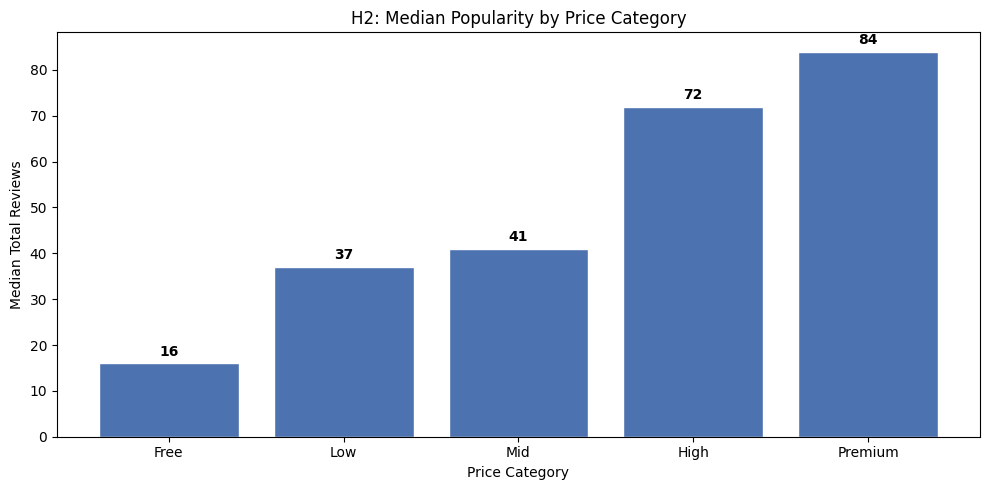

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("video_games_clean.csv")

# ============================================================
# HYPOTHESIS 2: Price Category vs Popularity
#
# H0: Popularity does not differ across price categories.
# H1: Popularity differs significantly across price categories.
#
# Test: Kruskal-Wallis Test (non-parametric ANOVA)
# ============================================================

bins   = [-1, 0, 30, 60, 80, 101]
labels = ["Free", "Low", "Mid", "High", "Premium"]
df["price_category"] = pd.cut(df["price"], bins=bins, labels=labels)

print("--- Descriptive Statistics ---")
print("Count per category:")
print(df["price_category"].value_counts().sort_index().to_string())
print("\nMedian reviews by category:")
print(df.groupby("price_category", observed=True)["total_reviews"].median().round(1).to_string())

groups = [group["total_reviews"].values
          for _, group in df.groupby("price_category", observed=True)]

stat, p = stats.kruskal(*groups)

print("\n--- Kruskal-Wallis Test ---")
print(f"Statistic : {stat:.4f}")
print(f"P-value   : {p:.6f}")

if p < 0.05:
    print("\nResult: REJECT H0 — Popularity differs significantly across price categories.")
else:
    print("\nResult: FAIL TO REJECT H0 — No significant difference across price categories.")

# ============================================================
# RESULTS & INTERPRETATION
#
# Category   |   n    | Median Reviews
# -----------|--------|---------------
# Free       | 81,930 |      3
# Low        |  7,759 |      6
# Mid        | 17,185 |     22
# High       | 11,311 |     50
# Premium    |  4,426 |     69
#
# H = 11,623.89   p < 0.001
#
# H0 is rejected. Popularity differs significantly across price
# categories. There is a clear positive relationship between
# price and median review count — higher-priced games tend to
# receive more reviews. This pattern likely reflects the fact
# that premium-priced games are typically produced by larger
# studios with bigger marketing budgets and established fan bases,
# which naturally drives higher engagement.
# ============================================================

# Visualization
cat_medians = df.groupby("price_category", observed=True)["total_reviews"].median()
plt.figure(figsize=(10, 5))
bars = plt.bar(cat_medians.index, cat_medians.values, color="#4C72B0", edgecolor="white")
for bar, val in zip(bars, cat_medians.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{int(val):,}", ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.title("H2: Median Popularity by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Median Total Reviews")
plt.tight_layout()
plt.savefig("h2_price_category.png", dpi=150)
plt.show()